# Notebook 1 — Stage 1: Binary Classifier (*Penyaringan*)
**Javanese OCR — Two-Stage Classification Pipeline**

Trains the **Stage 1 quality gate**: an EfficientNetB0-based binary classifier that filters
valid Aksara Jawa base characters from noise/artifacts before they reach the character recognizer.

| Aspect | Detail |
|--------|--------|
| **Input** | Grayscale `base.png` crop from density segmentation pipeline |
| **Output** | valid (pass to Stage 2) or noise (discard) |
| **Model** | EfficientNetB0 + grayscale adapter — two-phase training |
| **Data** | `../labeling_tool_density/dataset_binary/` |
| **Evaluation** | Accuracy, Precision, Recall, F1, ROC/AUC (BAB II Subbab 2.2.7) |

**Key improvement over base approach**: Class weights applied to compensate for
the ~2:1 valid/noise imbalance (3012 valid / 1500 noise — 482 original + 1018 augmented), explicit 80/10/10 train/val/test split.

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Section 0 — Setup

In [21]:
import os, json, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU        : {gpus or 'None — CPU only'}")
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Source: labeled crops from density_labeler.py --mode stage1
# Structure: dataset_binary/valid/*.jpg   dataset_binary/noise/*.jpg
DATASET_DIR = r"/content/drive/MyDrive/Dataset Skripsi/dataset_binary"
SPLIT_DIR   = "/content/drive/MyDrive/Dataset Skripsi/tahap1/splits"   # train/val/test dirs created here
MODEL_DIR   = "/content/drive/MyDrive/Dataset Skripsi/tahap1/model"
MODEL_PATH  = os.path.join(MODEL_DIR, "stage1_binary_classifier.keras")
CONFIG_PATH = os.path.join(MODEL_DIR, "stage1_config.json")

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE     = 128
BATCH_SIZE   = 64
EPOCHS       = 60
LR_HEAD      = 1e-3
LR_FINETUNE  = 1e-4
FINE_TUNE_AT = 100   # EfficientNetB0 layers from index >= this are fine-tuned
VAL_RATIO    = 0.10  # 10% validation
TEST_RATIO   = 0.10  # 10% held-out test (not seen during training)
RANDOM_SEED  = 42

os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
print("Config ready")

Config ready


---
## Section 1 — Dataset Preparation

> **Prerequisite**: Run `density_labeler.py --mode stage1` first to populate `dataset_binary/valid/` and `dataset_binary/noise/`.

In [23]:
def _count_class(base_dir, cls):
    p = os.path.join(base_dir, cls)
    if not os.path.exists(p):
        return 0
    return len([f for f in os.listdir(p)
                if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

n_valid = _count_class(DATASET_DIR, "valid")
n_noise = _count_class(DATASET_DIR, "noise")
total   = n_valid + n_noise

print(f"{'─'*45}")
print(f"  valid : {n_valid:>5}  ({n_valid / max(total, 1) * 100:.1f}%)")
print(f"  noise : {n_noise:>5}  ({n_noise / max(total, 1) * 100:.1f}%)")
print(f"  total : {total:>5}")
print(f"{'─'*45}")

if total == 0:
    raise RuntimeError("No data found. Run density_labeler.py --mode stage1 first.")
if n_valid > 0 and n_noise > 0:
    ratio = max(n_valid, n_noise) / min(n_valid, n_noise)
    print(f"  Imbalance ratio : {ratio:.1f}:1")
    print(f"  -> class_weight='balanced' will be applied during training")

─────────────────────────────────────────────
  valid :  3012  (66.8%)
  noise :  1500  (33.2%)
  total :  4512
─────────────────────────────────────────────
  Imbalance ratio : 2.0:1
  -> class_weight='balanced' will be applied during training


In [24]:
def create_stratified_split(src_dir, out_dir, val_ratio=0.10, test_ratio=0.10, seed=42):
    """Copy files to out_dir/{train,val,test}/{class}/ with stratified split."""
    random.seed(seed)
    classes = sorted([
        d for d in os.listdir(src_dir)
        if os.path.isdir(os.path.join(src_dir, d))
    ])
    for split in ("train", "val", "test"):
        for cls in classes:
            os.makedirs(os.path.join(out_dir, split, cls), exist_ok=True)

    print(f"Creating split in: {out_dir}")
    print(f"{'─'*50}")
    for cls in classes:
        imgs = sorted([
            f for f in os.listdir(os.path.join(src_dir, cls))
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))
        ])
        random.shuffle(imgs)
        n        = len(imgs)
        n_test   = max(1, int(n * test_ratio))
        n_val    = max(1, int(n * val_ratio))
        n_train  = n - n_val - n_test
        splits   = {
            "train": imgs[:n_train],
            "val":   imgs[n_train:n_train + n_val],
            "test":  imgs[n_train + n_val:],
        }
        for sname, sfiles in splits.items():
            for fname in sfiles:
                shutil.copy2(
                    os.path.join(src_dir, cls, fname),
                    os.path.join(out_dir, sname, cls, fname),
                )
        print(f"  {cls:<8}  train={len(splits['train']):>4}  val={len(splits['val']):>3}  test={len(splits['test']):>3}")
    print(f"{'─'*50}")


def _split_is_stale(split_dir, src_dir):
    expected = sum(
        len([f for f in os.listdir(os.path.join(src_dir, cls))
             if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        for cls in os.listdir(src_dir)
        if os.path.isdir(os.path.join(src_dir, cls))
    )
    if not os.path.exists(os.path.join(split_dir, "train")):
        return True
    actual = sum(
        len(os.listdir(os.path.join(split_dir, sp, cls)))
        for sp in ("train", "val", "test")
        for cls in ("valid", "noise")
        if os.path.exists(os.path.join(split_dir, sp, cls))
    )
    return actual != expected


if _split_is_stale(SPLIT_DIR, DATASET_DIR):
    if os.path.exists(SPLIT_DIR):
        shutil.rmtree(SPLIT_DIR)
    os.makedirs(SPLIT_DIR, exist_ok=True)
    create_stratified_split(DATASET_DIR, SPLIT_DIR, VAL_RATIO, TEST_RATIO, RANDOM_SEED)
else:
    print("Splits match source count — skipping.")

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR   = os.path.join(SPLIT_DIR, "val")
TEST_DIR  = os.path.join(SPLIT_DIR, "test")

Creating split in: /content/drive/MyDrive/Dataset Skripsi/tahap1/splits
──────────────────────────────────────────────────
  noise     train=1200  val=150  test=150
  valid     train=2410  val=301  test=301
──────────────────────────────────────────────────


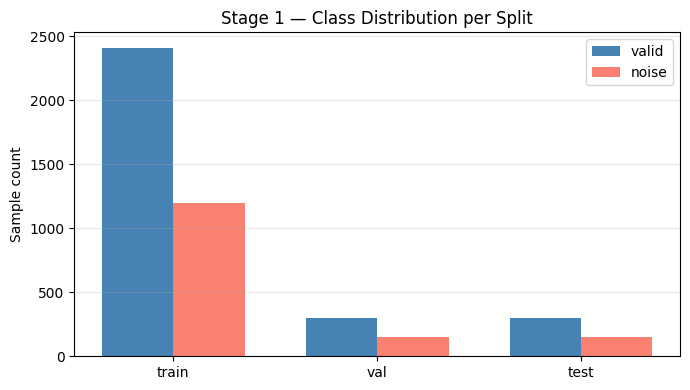

In [25]:
# Class distribution per split
splits_info = {}
for split, sdir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    splits_info[split] = {
        cls: len(os.listdir(os.path.join(sdir, cls)))
        if os.path.exists(os.path.join(sdir, cls)) else 0
        for cls in ("valid", "noise")
    }

fig, ax = plt.subplots(figsize=(7, 4))
x, bar_w = np.arange(3), 0.35
ax.bar(x - bar_w/2,
       [splits_info[s]["valid"] for s in ("train", "val", "test")],
       bar_w, label="valid", color="steelblue")
ax.bar(x + bar_w/2,
       [splits_info[s]["noise"] for s in ("train", "val", "test")],
       bar_w, label="noise", color="salmon")
ax.set_xticks(x); ax.set_xticklabels(["train", "val", "test"])
ax.set_ylabel("Sample count")
ax.set_title("Stage 1 — Class Distribution per Split")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

---
## Section 2 — Data Generators & Class Weights

In [26]:
# Augmentation for training only; horizontal_flip=False (Javanese is asymmetric)
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    shear_range=0.05,
    horizontal_flip=False,
    fill_mode="nearest",
)
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

_kw = dict(
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="grayscale",
    seed=RANDOM_SEED,
)
train_gen = train_datagen.flow_from_directory(TRAIN_DIR, shuffle=True,  **_kw)
val_gen   = val_test_datagen.flow_from_directory(VAL_DIR,   shuffle=False, **_kw)
test_gen  = val_test_datagen.flow_from_directory(TEST_DIR,  shuffle=False, **_kw)

print(f"Class map  : {train_gen.class_indices}")
print(f"Train      : {train_gen.samples:>5}")
print(f"Validation : {val_gen.samples:>5}")
print(f"Test       : {test_gen.samples:>5}")

# Class weights to handle valid/noise imbalance
cw = compute_class_weight(
    "balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes,
)
CLASS_WEIGHT = dict(enumerate(cw))
idx_map = {v: k for k, v in train_gen.class_indices.items()}
print(f"\nClass weights:")
for idx, w in CLASS_WEIGHT.items():
    print(f"  [{idx}] {idx_map[idx]:<8} : {w:.4f}")

Found 3610 images belonging to 2 classes.
Found 451 images belonging to 2 classes.
Found 451 images belonging to 2 classes.
Class map  : {'noise': 0, 'valid': 1}
Train      :  3610
Validation :   451
Test       :   451

Class weights:
  [0] noise    : 1.5042
  [1] valid    : 0.7490


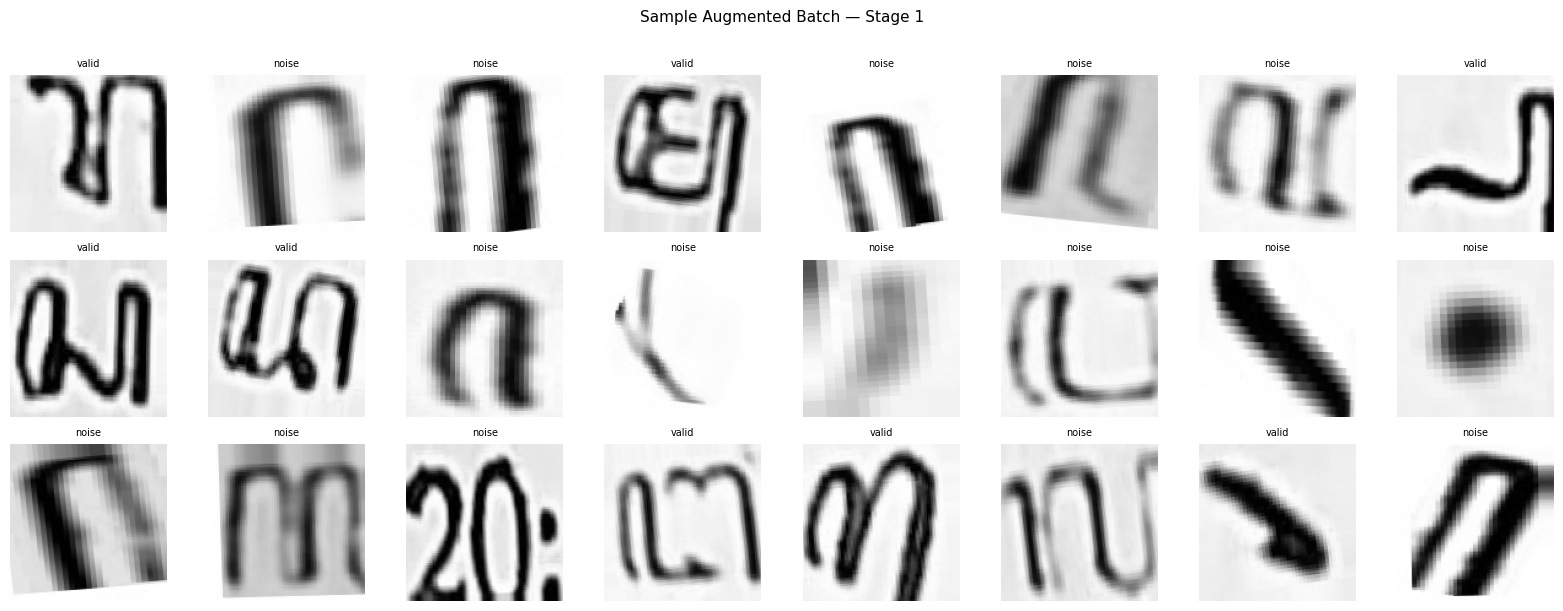

In [27]:
# Visualise a sample augmented batch
imgs, labels = next(train_gen)
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    if i < len(imgs):
        ax.imshow(imgs[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
        ax.set_title(idx_map[int(labels[i])], fontsize=7)
    ax.axis("off")
plt.suptitle("Sample Augmented Batch — Stage 1", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

---
## Section 3 — Model Architecture

**EfficientNetB0** used as training backbone.  
**Input trick**: Grayscale (1 channel) → 1×1 Conv → 3 channels → EfficientNetB0.

> After training, export to `.tflite` (Section 7) to get the mobile-optimised version
> equivalent to EfficientNet-Lite as referenced in the thesis.

In [28]:
def build_stage1_model(img_size=IMG_SIZE, fine_tune_at=FINE_TUNE_AT):
    inputs = keras.Input(shape=(img_size, img_size, 1), name="grayscale_in")

    # Grayscale -> 3-channel projection for EfficientNet compatibility
    x = layers.Conv2D(3, kernel_size=1, padding="same",
                      use_bias=False, name="ch_proj")(inputs)

    # Instantiate backbone with input_shape (not input_tensor) so the
    # imagenet weights (131 layers) load without layer-count mismatch.
    backbone = EfficientNetB0(
        include_top=False, weights="imagenet",
        input_shape=(img_size, img_size, 3), pooling="avg",
    )
    backbone.trainable = False

    x = backbone(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dropout(0.30, name="head_drop1")(x)
    x = layers.Dense(128, activation="relu", name="head_fc")(x)
    x = layers.Dropout(0.20, name="head_drop2")(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(inputs, out, name="Stage1_BinaryClassifier")
    return model, backbone


model, backbone = build_stage1_model()
model.summary(line_length=90)
trainable = sum(p.numpy().size for p in model.trainable_weights)
print(f"Trainable params (head only): {trainable:,}")

Model: "Stage1_BinaryClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ grayscale_in (InputLayer)             │ (None, 128, 128, 1)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ ch_proj (Conv2D)                      │ (None, 128, 128, 3)          │               3 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)           │ (None, 1280)                 │       4,049,571 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ head_bn (BatchNormalization)          │ (None, 1280)                 │           5,120 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ head_drop1 (Dropout)                  │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ head_fc (Dense)                       │ (None, 128)                  │         163,968 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ head_drop2 (Dropout)                  │ (None, 128)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ output (Dense)                        │ (None, 1)                    │             129 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 4,218,791 (16.09 MB)

 Trainable params: 166,660 (651.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Trainable params (head only): 166,660


---
## Section 4 — Two-Phase Training

| Phase | Backbone | LR | Note |
|-------|----------|----|------|
| **Phase 1** | Frozen | `LR_HEAD = 1e-3` | Train classification head only |
| **Phase 2** | Top layers unfrozen | `LR_FINETUNE = 1e-4` | Fine-tune layers ≥ `FINE_TUNE_AT` |

In [29]:
model.compile(
    optimizer=keras.optimizers.Adam(LR_HEAD),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

p1_path = MODEL_PATH.replace(".keras", "_phase1.keras")
callbacks_p1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=8,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5,
        patience=4, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        p1_path, monitor="val_auc", mode="max",
        save_best_only=True, verbose=1),
]

print("=" * 60)
print("PHASE 1 — Training classification head (backbone frozen)")
print("=" * 60)
history_p1 = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks_p1,
    class_weight=CLASS_WEIGHT,
)

PHASE 1 — Training classification head (backbone frozen)
Epoch 1/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.5886 - auc: 0.5893 - loss: 0.7612
Epoch 1: val_auc improved from None to 0.91089, saving model to /content/drive/MyDrive/Dataset Skripsi/tahap1/model/stage1_binary_classifier_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset Skripsi/tahap1/model/stage1_binary_classifier_phase1.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 926ms/step - accuracy: 0.6283 - auc: 0.6607 - loss: 0.7038 - val_accuracy: 0.6674 - val_auc: 0.9109 - val_loss: 0.6293 - learning_rate: 0.0010
Epoch 2/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.7572 - auc: 0.8169 - loss: 0.5335
Epoch 2: val_auc improved from 0.91089 to 0.92186, saving model to /content/drive/MyDrive/Dataset Skripsi/tahap1/model/stage1_binary_classifier_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Dataset Skripsi/tahap1/model/stage1_binary_classifier_phase1.keras
57/57 ━━

In [30]:
backbone.trainable = True
for layer in backbone.layers[:FINE_TUNE_AT]:
    layer.trainable = False

n_trainable = sum(1 for l in backbone.layers if l.trainable)
print(f"Unfreezing {n_trainable} backbone layers (index >= {FINE_TUNE_AT})")

model.compile(
    optimizer=keras.optimizers.Adam(LR_FINETUNE),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

callbacks_p2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=10,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.3,
        patience=5, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor="val_auc", mode="max",
        save_best_only=True, verbose=1),
]

print("=" * 60)
print(f"PHASE 2 — Fine-tuning top backbone layers (LR={LR_FINETUNE})")
print("=" * 60)
history_p2 = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks_p2,
    class_weight=CLASS_WEIGHT,
)

Unfreezing 139 backbone layers (index >= 100)
PHASE 2 — Fine-tuning top backbone layers (LR=0.0001)
Epoch 1/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.8114 - auc: 0.8829 - loss: 0.6671
Epoch 1: val_auc improved from None to 0.95430, saving model to /content/drive/MyDrive/Dataset Skripsi/tahap1/model/stage1_binary_classifier.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset Skripsi/tahap1/model/stage1_binary_classifier.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8587 - auc: 0.9235 - loss: 0.4846 - val_accuracy: 0.7982 - val_auc: 0.9543 - val_loss: 0.4129 - learning_rate: 1.0000e-04
Epoch 2/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9112 - auc: 0.9750 - loss: 0.2059
Epoch 2: val_auc did not improve from 0.95430
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 365ms/step - accuracy: 0.9166 - auc: 0.9743 - loss: 0.2086 - val_accuracy: 0.6674 - val_auc: 0.9183 - val_loss: 0.4915 - learning_rate: 1.0000e-04
Epoch 3/60
57/57 ━━━━━━━━━━━━━━━━━━

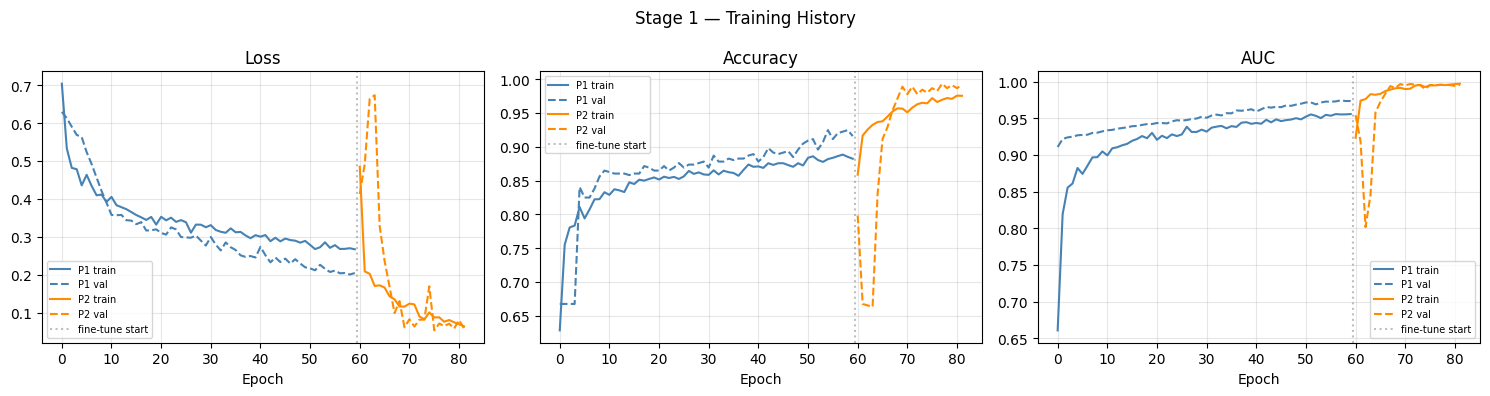

In [31]:
# Combined training history (Phase 1 + Phase 2)
def plot_two_phase_history(h1, h2):
    offset   = len(h1.history["loss"])
    metrics  = [("loss", "Loss"), ("accuracy", "Accuracy"), ("auc", "AUC")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (m, title) in zip(axes, metrics):
        if m not in h1.history:
            continue
        e1 = range(offset)
        e2 = range(offset, offset + len(h2.history.get(m, [])))
        ax.plot(e1, h1.history[m],                "steelblue",  label="P1 train")
        ax.plot(e1, h1.history.get(f"val_{m}", []),"steelblue",  label="P1 val",  ls="--")
        ax.plot(e2, h2.history.get(m, []),         "darkorange", label="P2 train")
        ax.plot(e2, h2.history.get(f"val_{m}", []),"darkorange", label="P2 val",  ls="--")
        ax.axvline(offset - 0.5, color="gray", ls=":", alpha=0.5, label="fine-tune start")
        ax.set_title(title); ax.set_xlabel("Epoch")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.suptitle("Stage 1 — Training History", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, "stage1_training_curves.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

plot_two_phase_history(history_p1, history_p2)

---
## Section 5 — Evaluation on Test Set

Metrics correspond to BAB II Subbab 2.2.7 (Powers, 2011):
Accuracy (Rumus 2.7), Precision (2.8), Recall (2.9), F1-Score (2.10).

Test set evaluation:
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - accuracy: 0.9867 - auc: 0.9977 - loss: 0.0545
  loss        : 0.0545
  compile_metrics: 0.9867


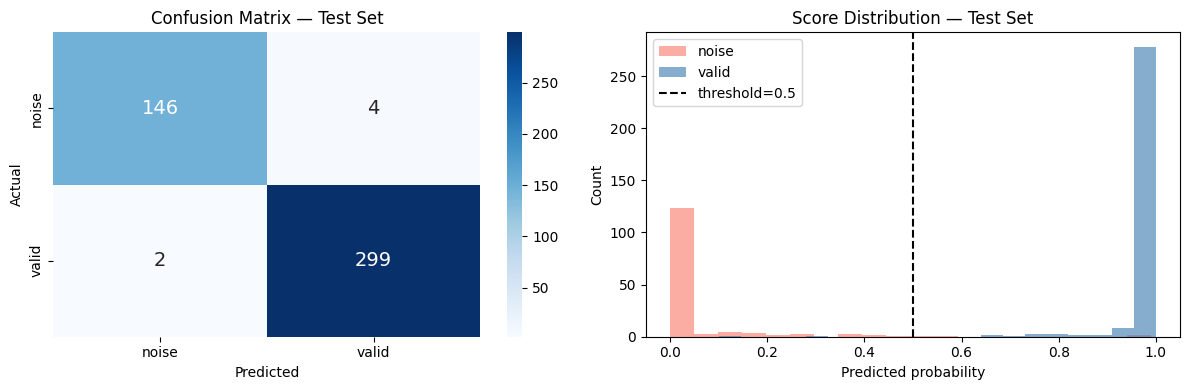


              precision    recall  f1-score   support

       noise     0.9865    0.9733    0.9799       150
       valid     0.9868    0.9934    0.9901       301

    accuracy                         0.9867       451
   macro avg     0.9866    0.9833    0.9850       451
weighted avg     0.9867    0.9867    0.9867       451


Metrik (BAB II Subbab 2.2.7):
  TP=299  TN=146  FP=4  FN=2
  Accuracy  = 0.9867  (Rumus 2.7)
  Precision = 0.9868  (Rumus 2.8)
  Recall    = 0.9934  (Rumus 2.9)
  F1-Score  = 0.9901  (Rumus 2.10)


In [32]:
print("Test set evaluation:")
print("=" * 40)
test_results = model.evaluate(test_gen, verbose=1)
for name, val in zip(model.metrics_names, test_results):
    print(f"  {name:<12}: {val:.4f}")

# Predictions on test set
test_gen.reset()
y_prob = model.predict(test_gen, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes
cls    = list(test_gen.class_indices.keys())

# Confusion matrix
cm  = confusion_matrix(y_true, y_pred)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cls, yticklabels=cls, ax=ax1,
            annot_kws={"size": 14})
ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")
ax1.set_title("Confusion Matrix — Test Set")

# Score distribution by class
class_map = {v: k for k, v in test_gen.class_indices.items()}
colors    = {"noise": "salmon", "valid": "steelblue"}
for val_idx, label in class_map.items():
    mask = y_true == val_idx
    ax2.hist(y_prob[mask], bins=20, alpha=0.65,
             color=colors.get(label, "gray"), label=label)
ax2.axvline(0.5, color="black", ls="--", label="threshold=0.5")
ax2.set_xlabel("Predicted probability")
ax2.set_title("Score Distribution — Test Set")
ax2.legend(); ax2.set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "stage1_confusion_test.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("\n" + classification_report(y_true, y_pred, target_names=cls, digits=4))

# Manual metric computation (matching BAB II formulas)
tn, fp, fn, tp = cm.ravel()
acc  = (tp + tn) / (tp + tn + fp + fn)
prec = tp / (tp + fp) if (tp + fp) else 0.0
rec  = tp / (tp + fn) if (tp + fn) else 0.0
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
print(f"\nMetrik (BAB II Subbab 2.2.7):")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"  Accuracy  = {acc:.4f}  (Rumus 2.7)")
print(f"  Precision = {prec:.4f}  (Rumus 2.8)")
print(f"  Recall    = {rec:.4f}  (Rumus 2.9)")
print(f"  F1-Score  = {f1:.4f}  (Rumus 2.10)")

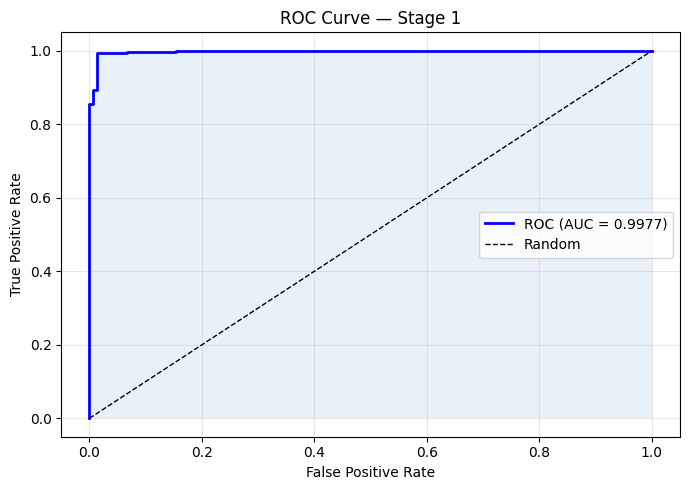

AUC = 0.9977


In [33]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, "b-", linewidth=2, label=f"ROC (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.fill_between(fpr, tpr, alpha=0.10)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Stage 1")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "stage1_roc_curve.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC = {roc_auc:.4f}")

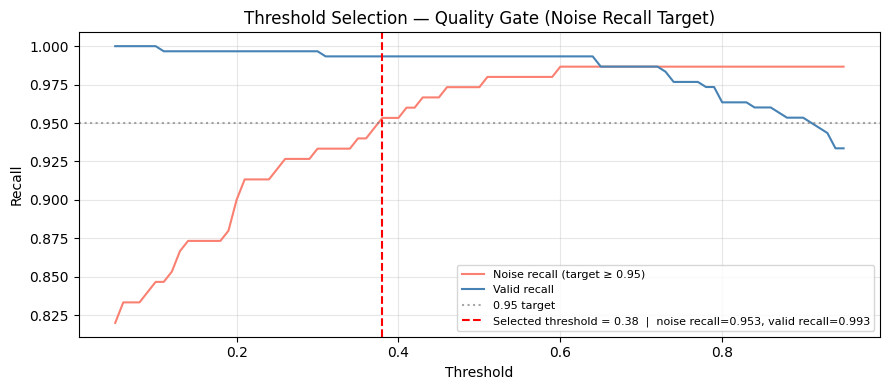

  Selected threshold  : 0.38
  Noise recall        : 0.9533
  Valid recall        : 0.9934
  F1 (valid) at this t: 0.9852


In [34]:
# Threshold selection — quality gate objective: reject at least 95% of noise.
# Sweep thresholds and find the least aggressive value where noise recall >= 0.95,
# then among those candidates pick the one with the highest valid recall (fewest lost characters).
noise_idx = train_gen.class_indices["noise"]   # 0
valid_idx  = train_gen.class_indices["valid"]  # 1

thresholds    = np.linspace(0.05, 0.95, 91)
noise_recalls = []
valid_recalls = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    noise_mask = (y_true == noise_idx)
    noise_recalls.append(np.mean(preds[noise_mask] == noise_idx))
    valid_recalls.append(np.mean(preds[~noise_mask] == valid_idx))

noise_recalls = np.array(noise_recalls)
valid_recalls = np.array(valid_recalls)

NOISE_RECALL_TARGET = 0.95
candidates = thresholds[noise_recalls >= NOISE_RECALL_TARGET]

if len(candidates) > 0:
    cand_valid_r = valid_recalls[noise_recalls >= NOISE_RECALL_TARGET]
    best_t = float(candidates[np.argmax(cand_valid_r)])
else:
    best_t = float(thresholds[np.argmax(noise_recalls)])
    print(f"WARNING: noise recall {NOISE_RECALL_TARGET} not reachable — using best available threshold")

best_idx      = np.argmin(np.abs(thresholds - best_t))
nr_at_best    = float(noise_recalls[best_idx])
vr_at_best    = float(valid_recalls[best_idx])
best_f1       = f1_score(y_true, (y_prob >= best_t).astype(int), zero_division=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, noise_recalls, color="salmon",    label="Noise recall (target ≥ 0.95)")
ax.plot(thresholds, valid_recalls, color="steelblue", label="Valid recall")
ax.axhline(NOISE_RECALL_TARGET, color="gray", ls=":", alpha=0.7, label=f"{NOISE_RECALL_TARGET} target")
ax.axvline(best_t, color="red", ls="--",
           label=f"Selected threshold = {best_t:.2f}  |  noise recall={nr_at_best:.3f}, valid recall={vr_at_best:.3f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Recall")
ax.set_title("Threshold Selection — Quality Gate (Noise Recall Target)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "stage1_threshold_selection.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"  Selected threshold  : {best_t:.2f}")
print(f"  Noise recall        : {nr_at_best:.4f}")
print(f"  Valid recall        : {vr_at_best:.4f}")
print(f"  F1 (valid) at this t: {best_f1:.4f}")

Found 451 images belonging to 2 classes.
Misclassified: 9 / 451


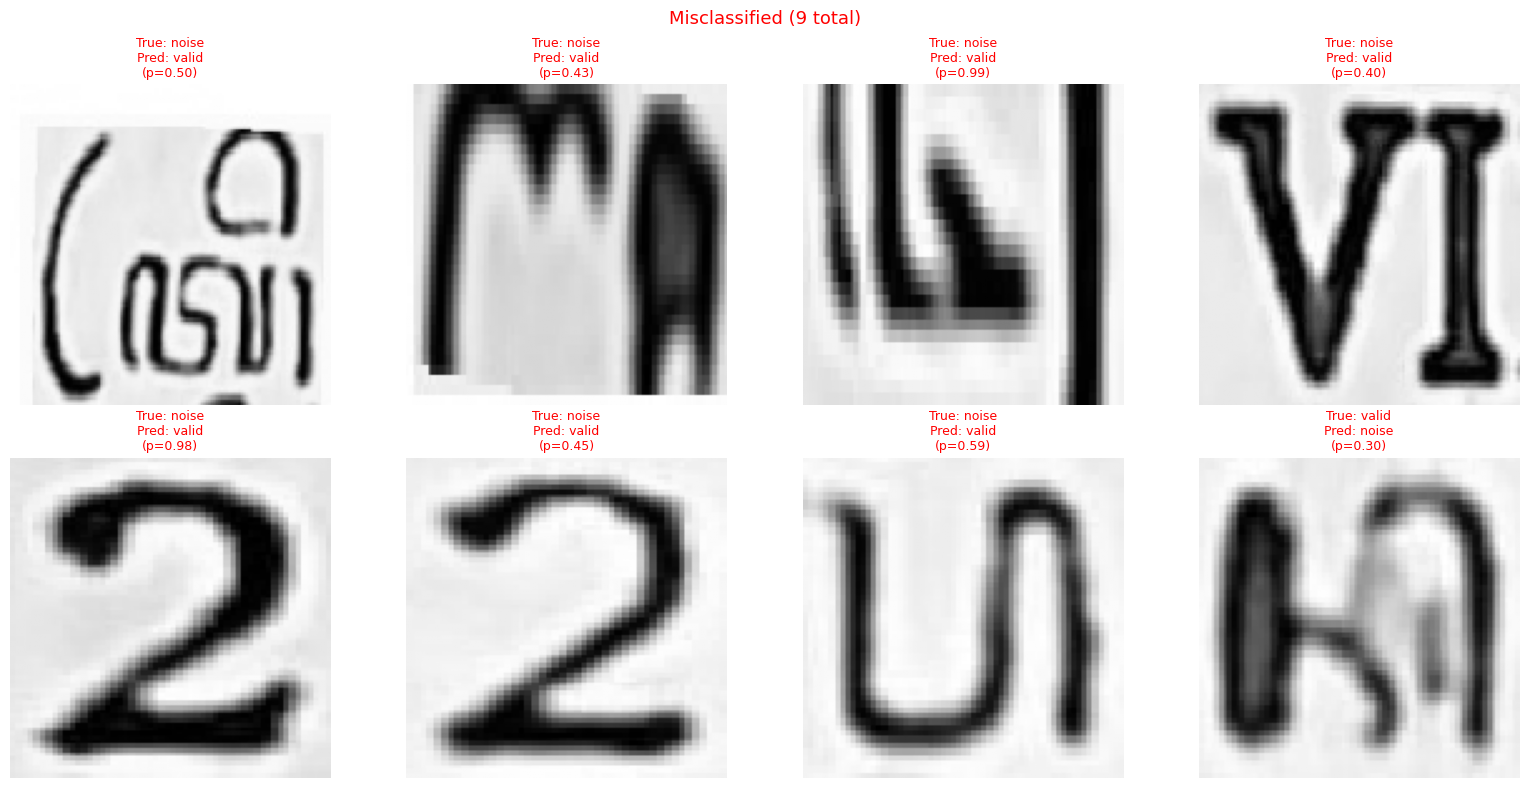

In [35]:
# Misclassification grid (using best_t threshold)
single_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    class_mode="binary",
    color_mode="grayscale",
    shuffle=False,
    seed=RANDOM_SEED,
)
misclassified = []
for i in range(single_gen.samples):
    img_b, lbl_b = single_gen[i]
    p    = model.predict(img_b, verbose=0)[0][0]
    pred = int(p >= best_t)
    true = int(lbl_b[0])
    if pred != true:
        misclassified.append({
            "path": single_gen.filepaths[i],
            "true": cls[true], "pred": cls[pred], "prob": float(p),
        })

print(f"Misclassified: {len(misclassified)} / {single_gen.samples}")
if misclassified:
    n_show = min(8, len(misclassified))
    cols   = max(1, (n_show + 1) // 2)
    fig, axes = plt.subplots(2, cols, figsize=(4 * cols, 8))
    for i, item in enumerate(misclassified[:n_show]):
        ax  = axes.flat[i]
        img = tf.keras.utils.load_img(
            item["path"], target_size=(IMG_SIZE, IMG_SIZE), color_mode="grayscale")
        ax.imshow(np.array(img), cmap="gray")
        ax.set_title(
            f"True: {item['true']}\nPred: {item['pred']}\n(p={item['prob']:.2f})",
            fontsize=9, color="red")
        ax.axis("off")
    for i in range(n_show, len(axes.flat)):
        axes.flat[i].axis("off")
    plt.suptitle(f"Misclassified ({len(misclassified)} total)",
                 fontsize=13, color="red")
    plt.tight_layout(); plt.show()
else:
    print("No misclassifications on test set!")

---
## Section 6 — Save Model & Config

In [36]:
# Keras model
model.save(MODEL_PATH)
print(f"Model  -> {MODEL_PATH}")

# Config JSON consumed by inference_compose.py
config = {
    "model_path":    MODEL_PATH,
    "img_size":      IMG_SIZE,
    "threshold":     best_t,
    "class_indices": train_gen.class_indices,
    "valid_label":   "valid",
    "roc_auc":       round(float(roc_auc), 4),
    "best_f1":       round(float(best_f1), 4),
}
with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)
print(f"Config -> {CONFIG_PATH}")
print(json.dumps(config, indent=2))

# TFLite export (equivalent to EfficientNet-Lite for mobile deployment)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()
tflite_path  = MODEL_PATH.replace(".keras", ".tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_bytes)
print(f"TFLite -> {tflite_path}  ({os.path.getsize(tflite_path) / 1024:.1f} KB)")

Model  -> /content/drive/MyDrive/Dataset Skripsi/tahap1/model/stage1_binary_classifier.keras
Config -> /content/drive/MyDrive/Dataset Skripsi/tahap1/model/stage1_config.json
{
  "model_path": "/content/drive/MyDrive/Dataset Skripsi/tahap1/model/stage1_binary_classifier.keras",
  "img_size": 128,
  "threshold": 0.37999999999999995,
  "class_indices": {
    "noise": 0,
    "valid": 1
  },
  "valid_label": "valid",
  "roc_auc": 0.9977,
  "best_f1": 0.9852
}
Saved artifact at '/tmp/tmp_84eqx0f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='grayscale_in')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135975848886096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135978582068496: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135978582069264: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135978394232080: TensorSpec